# Model Analysis and Explainability

## Objective

Analyze the behavior of the trained machine learning models using feature importance, explainability techniques, ROC analysis, and error analysis.

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap

In [2]:
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted",
    "num_root","num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate",
    "srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

train = pd.read_csv(
    "../data/raw/KDDTrain+.txt",
    names=columns
)

test = pd.read_csv(
    "../data/raw/KDDTest+.txt",
    names=columns
)

print(train.head())
print(test.head())
print(train.shape)


   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

In [3]:
train["binary_label"] = train["label"].apply(lambda x: 0 if x == "normal" else 1)

test["binary_label"] = test["label"].apply(lambda x: 0 if x == "normal" else 1)

In [4]:
X_train = train.drop(columns=["label", "binary_label", "difficulty"])
X_test = test.drop(columns=["label", "binary_label", "difficulty"])

y_train = train["binary_label"]
y_test = test["binary_label"]

In [5]:
preprocessor = joblib.load("../models/preprocessor.pkl")

In [6]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="gini",
        max_depth=20,
        min_samples_split=5,
        random_state=42
    ))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        eval_metric="logloss",
        random_state=42
    ))
])

lgbm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        num_leaves=31,
        random_state=42
    ))
])

models = {
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "LightGBM": lgbm_pipeline
}

for model in models.values():
    model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 58630, number of negative: 67343
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006546 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3296
[LightGBM] [Info] Number of data points in the train set: 125973, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465417 -> initscore=-0.138552
[LightGBM] [Info] Start training from score -0.138552


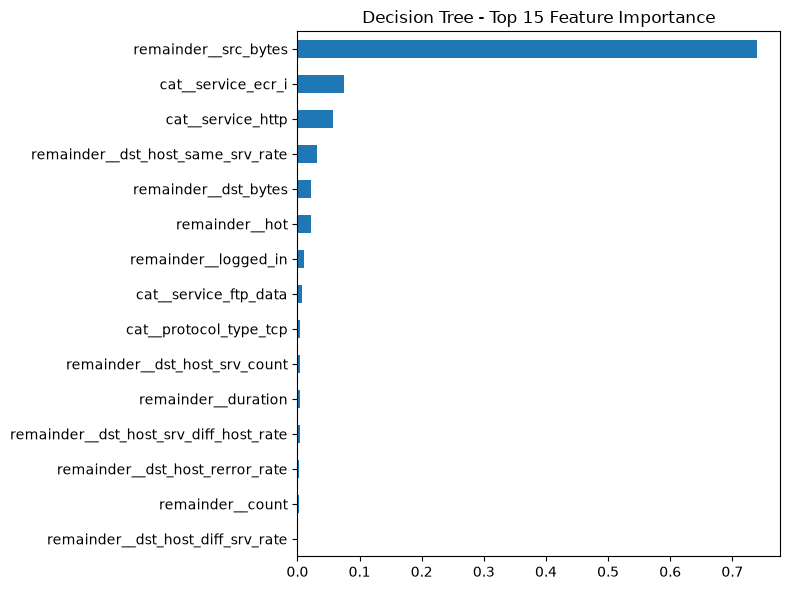

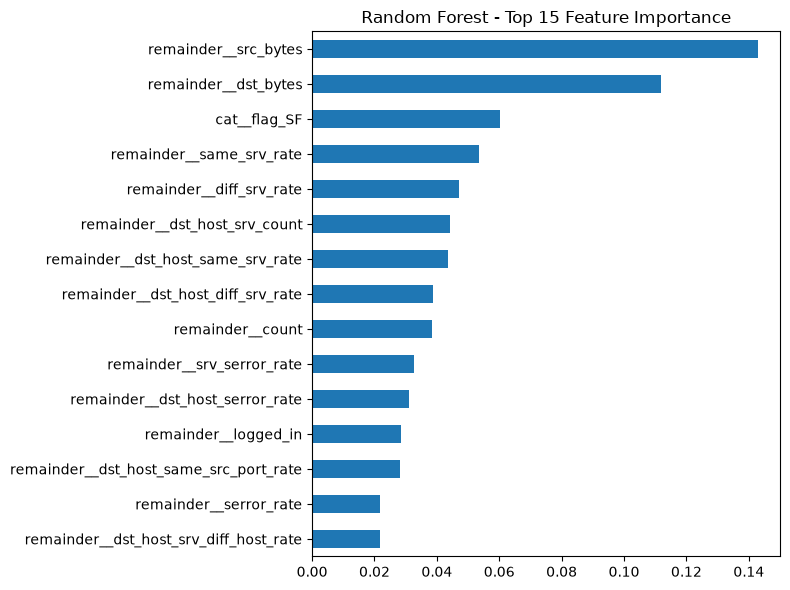

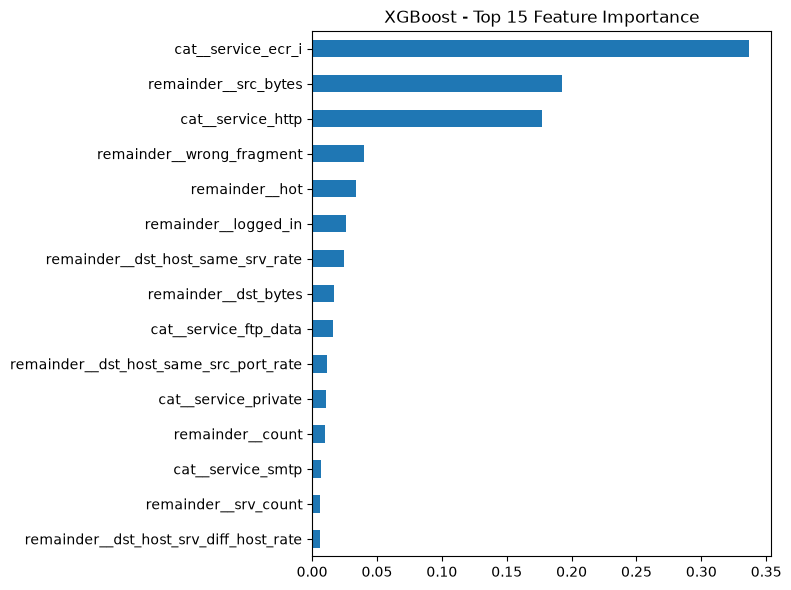

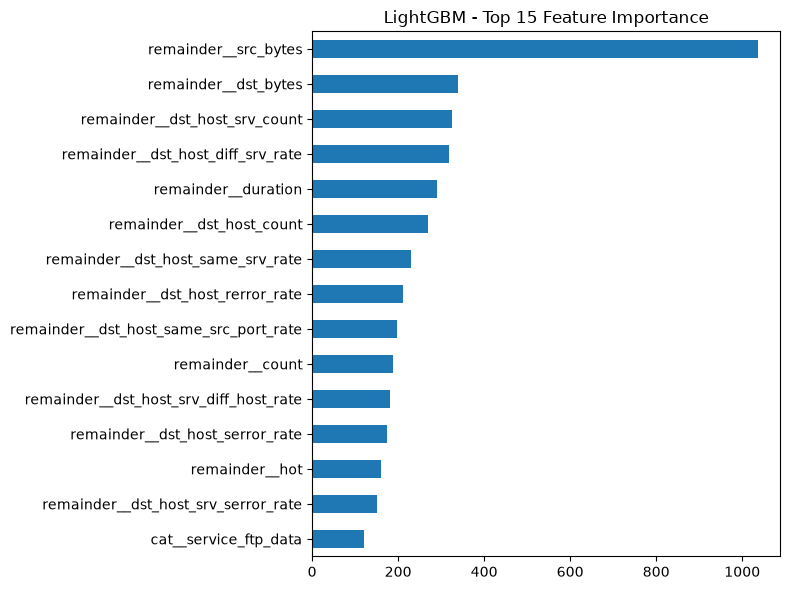

In [7]:
feature_names = preprocessor.get_feature_names_out()

for name, model in models.items():

    clf = model.named_steps["classifier"]

    importance = pd.Series(
        clf.feature_importances_,
        index=feature_names
    )

    top_features = importance.sort_values(
        ascending=False
    ).head(15)

    plt.figure(figsize=(8,6))

    top_features.sort_values().plot(kind="barh")

    plt.title(f"{name} - Top 15 Feature Importance")

    plt.tight_layout()

    plt.show()

In [8]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

explainer = shap.TreeExplainer(
    xgb_pipeline.named_steps["classifier"]
)

shap_values = explainer.shap_values(
    X_test_processed
)

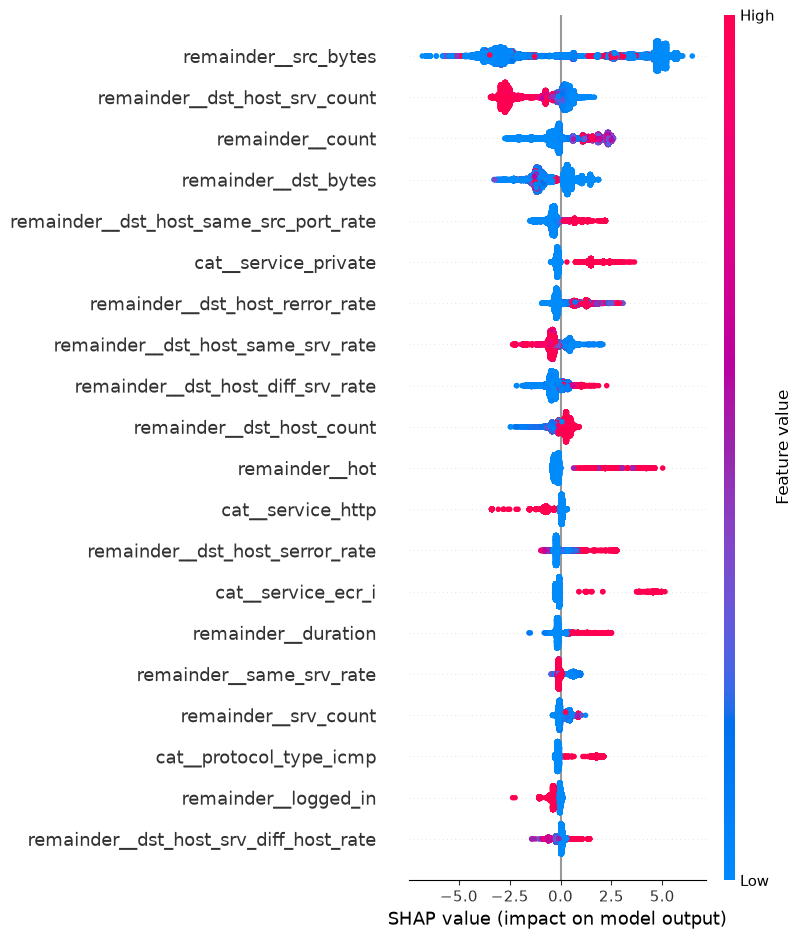

In [9]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

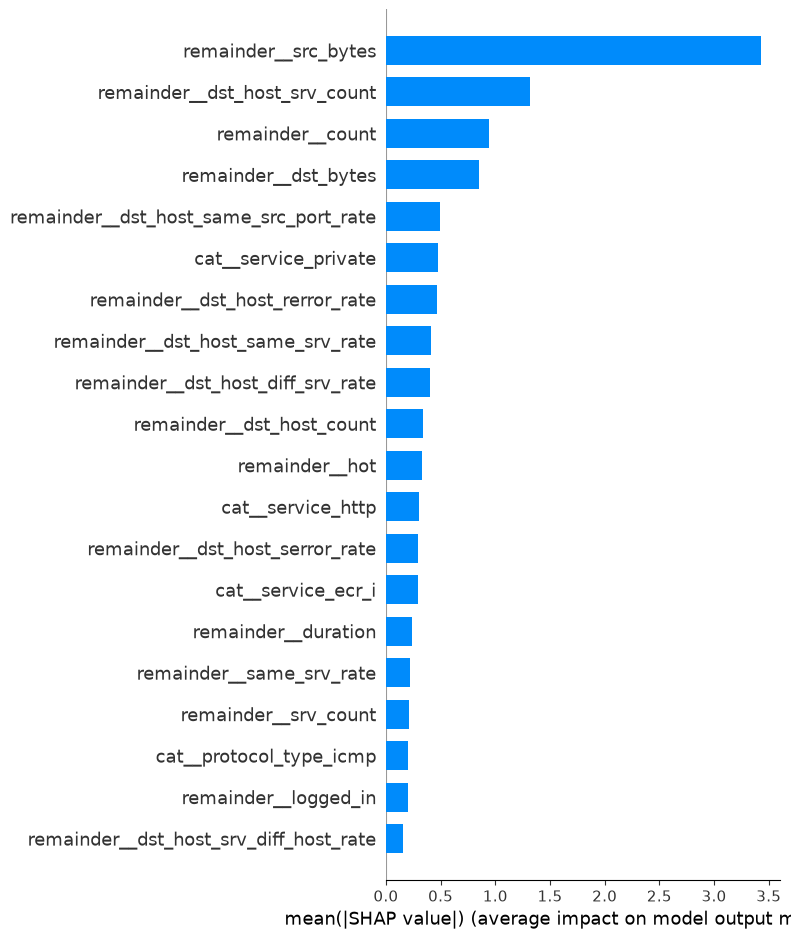

In [10]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar"
)

<Figure size 500x500 with 0 Axes>

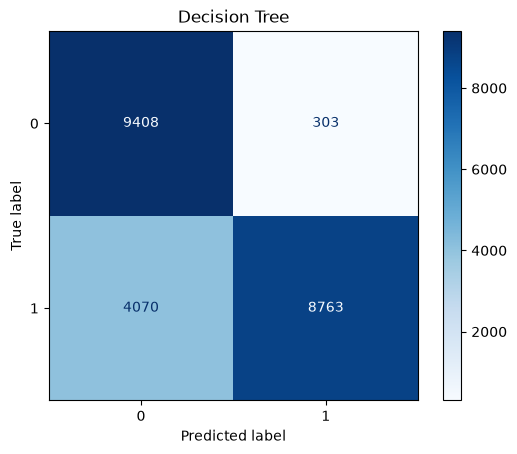

<Figure size 500x500 with 0 Axes>

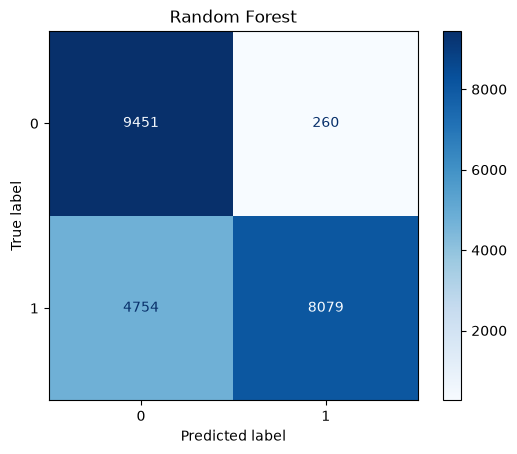

<Figure size 500x500 with 0 Axes>

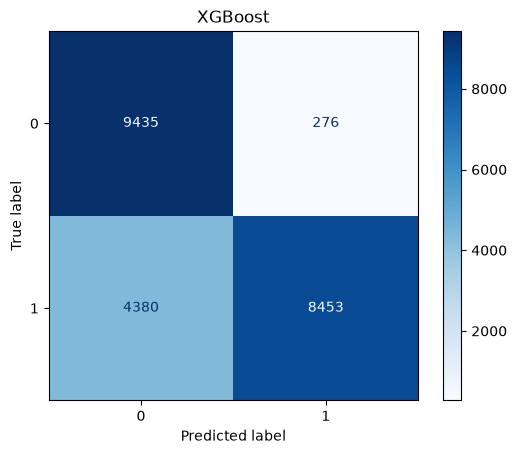

/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


<Figure size 500x500 with 0 Axes>

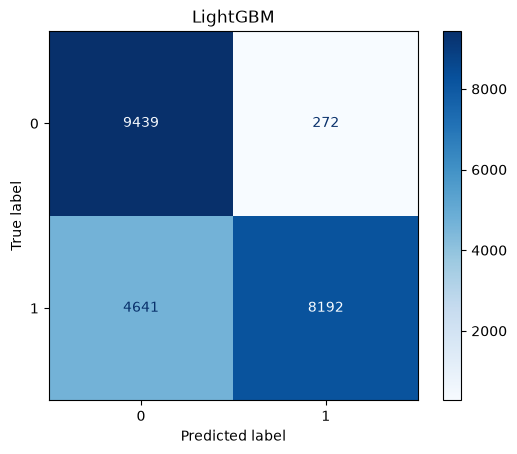

In [11]:
for name, model in models.items():

    plt.figure(figsize=(5,5))

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        cmap="Blues"
    )

    plt.title(name)

    plt.show()

In [12]:
pred = xgb_pipeline.predict(X_test)

fp = X_test[
    (y_test == 0) &
    (pred == 1)
]

print(fp.head())

print("False Positives:", len(fp))

     duration protocol_type  service  flag  src_bytes  dst_bytes  land  \
33          0           udp  private    SF          1          1     0   
331         0           tcp  private    S1          2     834163     0   
427         0           tcp    other  RSTR          0          0     0   
433         0           udp  private    SF         28          0     0   
453         0           udp  private    SF          1          0     0   

     wrong_fragment  urgent  hot  ...  dst_host_count  dst_host_srv_count  \
33                0       0    0  ...             255                   3   
331               0       0    6  ...             255                   2   
427               0       0    0  ...             255                   1   
433               3       0    0  ...             255                  80   
453               0       0    0  ...             255                  11   

     dst_host_same_srv_rate  dst_host_diff_srv_rate  \
33                     0.01          

In [13]:
fn = X_test[
    (y_test == 1) &
    (pred == 0)
]

print(fn.head())

print("False Negatives:", len(fn))

    duration protocol_type service  flag  src_bytes  dst_bytes  land  \
4          1           tcp  telnet  RSTO          0         15     0   
7          0           tcp  telnet    SF        129        174     0   
9          0           tcp     ftp    SF         26        157     0   
10         0           tcp  telnet    SF          0          0     0   
35         0           tcp   imap4  RSTO          0         44     0   

    wrong_fragment  urgent  hot  ...  dst_host_count  dst_host_srv_count  \
4                0       0    0  ...              29                  86   
7                0       0    0  ...             255                 255   
9                0       0    0  ...              52                  26   
10               0       0    0  ...             255                 128   
35               0       0    0  ...             185                  59   

    dst_host_same_srv_rate  dst_host_diff_srv_rate  \
4                     0.31                    0.17   
7 

/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


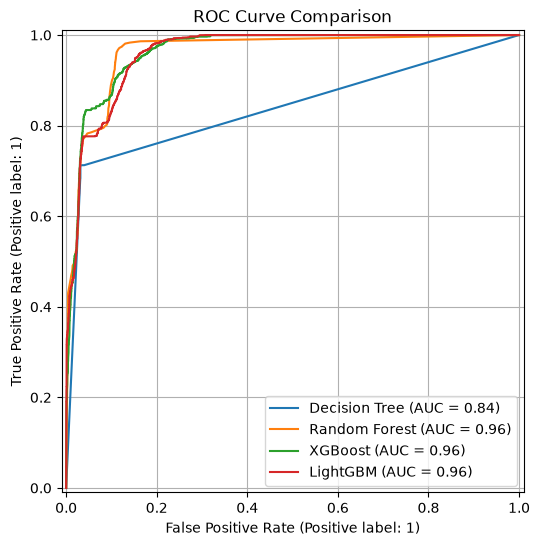

In [14]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=plt.gca(),
        name=name
    )

plt.title("ROC Curve Comparison")

plt.grid()

plt.show()

/Users/diffuse/Repositories/IDS_PROJECT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


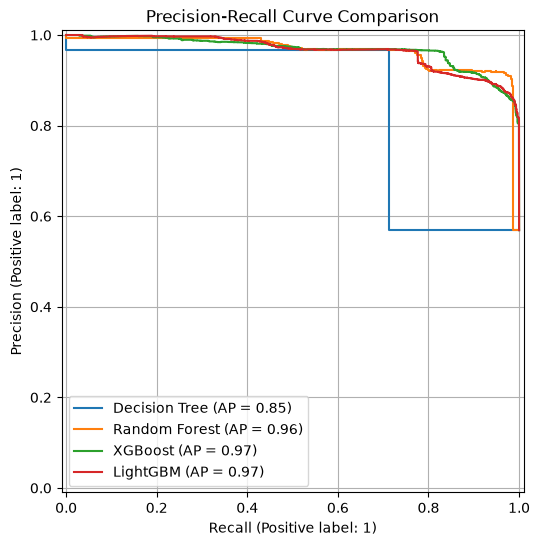

In [15]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    PrecisionRecallDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=plt.gca(),
        name=name
    )

plt.title("Precision-Recall Curve Comparison")

plt.grid()

plt.show()

# This is the end of notebook 5

* Decision Tree achieved the highest test accuracy.
* XGBoost and LightGBM achieved higher ROC-AUC, indicating stronger ranking capability.
* Precision was consistently higher than recall, showing the models were conservative in predicting attacks.
* The official NSL-KDD test set is substantially more challenging than cross-validation on the training set.